In [2]:
import pandas as pd
import requests
import json
import csv
import re
import boto3
import gzip
import io
import wget
import urllib.request
import os
import random
from pathlib import Path
from botocore import UNSIGNED
from botocore.client import Config
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from PIL.ExifTags import TAGS
import exifread
import openfoodfacts
from collections import defaultdict
from ipywidgets import interact, IntSlider, Dropdown
import ipywidgets as widgets
import seaborn

pd.set_option('display.max_columns', None)


In [8]:
chunk_iter = pd.read_csv(
    "en.openfoodfacts.org.products.csv",
    sep="\t",
    engine="python",
    quoting=csv.QUOTE_NONE,
    on_bad_lines="skip",
    chunksize=1000000
)

first_chunk = next(chunk_iter)

In [9]:
first_chunk.head()


,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,product_name,abbreviated_product_name,generic_name,quantity,packaging,packaging_tags,packaging_en,packaging_text,brands,brands_tags,brands_en,categories,categories_tags,categories_en,origins,origins_tags,origins_en,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_en,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_en,ingredients_text,ingredients_tags,ingredients_analysis_tags,allergens,allergens_en,traces,traces_tags,traces_en,serving_size,serving_quantity,no_nutrition_data,additives_n,additives,additives_tags,additives_en,nutriscore_score,nutriscore_grade,nova_group,pnns_groups_1,pnns_groups_2,food_groups,food_groups_tags,food_groups_en,states,states_tags,states_en,brand_owner,environmental_score_score,environmental_score_grade,nutrient_levels_tags,product_quantity,owner,data_quality_errors_tags,unique_scans_n,popularity_tags,completeness,last_image_t,last_image_datetime,main_category,main_category_en,image_url,image_small_url,image_ingredients_url,image_ingredients_small_url,image_nutrition_url,image_nutrition_small_url,energy-kj_100g,energy-kcal_100g,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,unsaturated-fat_100g,monounsaturated-fat_100g,omega-9-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,omega-6-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,added-sugars_100g,sucrose_100g,glucose_100g,fructose_100g,galactose_100g,lactose_100g,maltose_100g,maltodextrins_100g,psicose_100g,starch_100g,polyols_100g,erythritol_100g,isomalt_100g,maltitol_100g,sorbitol_100g,fiber_100g,soluble-fiber_100g,polydextrose_100g,insoluble-fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,added-salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,methylsulfonylmethane_100g,hydroxymethylbutyrate_100g,ph_100g,fruits-vegetables-legumes_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,glycemic-index_100g,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1.740205e+09,2025-02-22T06:23:42Z,Limonade artisanale a la rose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en:fr,en:france,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,NaN,unknown,unknown,NaN,NaN,NaN,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","To be completed,Nutrition facts to be complete...",NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,0.1625,1.733085e+09,202

In [10]:
len(first_chunk)

1000000

In [13]:
first_chunk['image_url'][9999]

'https://images.openfoodfacts.org/images/products/000/110/700/1390/front_fr.3.400.jpg'

In [27]:
test = 'https://images.openfoodfacts.org/images/products/002/114/002/4329/front_en.9.full.jpg'
test

'https://images.openfoodfacts.org/images/products/002/114/002/4329/front_en.9.full.jpg'

In [17]:
base_url = "https://images.openfoodfacts.org/images/products"

In [25]:
folder_name = str(first_chunk["code"][99996])
if len(folder_name) > 8:
        folder_name = re.sub(r'(...)(...)(...)(.*)', r'\1/\2/\3/\4', folder_name)
folder_name

'211/400/243/29'

# Open Food Fact Images - AWS S3 Bucket

In [156]:
N_IMAGES = 100

OUTPUT_DIR = "off_aws_images"

BUCKET_NAME = "openfoodfacts-images"

BUCKET_URL = "https://openfoodfacts-images.s3.eu-west-3.amazonaws.com/"

In [157]:
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

In [158]:
s3 = boto3.client(
    "s3",
    config=Config(signature_version=UNSIGNED)
)

/Users/stevenlanciotti/Working_Desktop/DataSci_210/OpenFoodFacts/.venv/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


In [159]:
response = s3.list_objects_v2(
    Bucket=BUCKET_NAME
)

In [160]:
response['Contents']

[{'Key': 'README.md',
  'LastModified': datetime.datetime(2023, 5, 13, 10, 0, 29, tzinfo=tzutc()),
  'ETag': '"059e12e58791699f80921f4275f3dc8e"',
  'Size': 1849,
  'StorageClass': 'STANDARD'},
 {'Key': 'data/000/000/000/0000/1.400.jpg',
  'LastModified': datetime.datetime(2026, 1, 3, 15, 50, 2, tzinfo=tzutc()),
  'ETag': '"96b9832dc3bcbd8e998249fe80c7e2be"',
  'ChecksumAlgorithm': ['CRC64NVME'],
  'ChecksumType': 'FULL_OBJECT',
  'Size': 25976,
  'StorageClass': 'STANDARD'},
 {'Key': 'data/000/000/000/0000/1.jpg',
  'LastModified': datetime.datetime(2026, 1, 3, 15, 50, 2, tzinfo=tzutc()),
  'ETag': '"4542121be1c76c428202528f133b9dbb"',
  'ChecksumAlgorithm': ['CRC64NVME'],
  'ChecksumType': 'FULL_OBJECT',
  'Size': 134484,
  'StorageClass': 'INTELLIGENT_TIERING'},
 {'Key': 'data/000/000/000/0000/1.json.gz',
  'LastModified': datetime.datetime(2026, 1, 3, 15, 50, 2, tzinfo=tzutc()),
  'ETag': '"de8f5947d1037f1d6c826c5449cf19f7"',
  'ChecksumAlgorithm': ['CRC64NVME'],
  'ChecksumType': 

In [161]:
page_df = pd.DataFrame(response['Contents'])

In [162]:
page_df

,Key,LastModified,ETag,Size,StorageClass,ChecksumAlgorithm,ChecksumType
0,README.md,2023-05-13 10:00:29+00:00,"""059e12e58791699f80921f4275f3dc8e""",1849,STANDARD,NaN,NaN
1,data/000/000/000/0000/1.400.jpg,2026-01-03 15:50:02+00:00,"""96b9832dc3bcbd8e998249fe80c7e2be""",25976,STANDARD,[CRC64NVME],FULL_OBJECT
2,data/000/000/000/0000/1.jpg,2026-01-03 15:50:02+00:00,"""4542121be1c76c428202528f133b9dbb""",134484,INTELLIGENT_TIERING,[CRC64NVME],FULL_OBJECT
3,data/000/000/000/0000/1.json.gz,2026-01-03 15:50:02+00:00,"""de8f5947d1037f1d6c826c5449cf19f7""",408,STANDARD,[CRC64NVME],FULL_OBJECT
4,data/000/000/000/0000/10.400.jpg,2024-10-16 00:24:44+00:00,"""6d02535f66ebef483fc258440fbe00af""",31967,STANDARD,NaN,NaN
...,...,...,...,...,...,...,...
995,data/000/000/000/0036/5.json.gz,2024-10-11 21:15:31+00:00,"""ae3a766216c320c7c4eafc786edc607f""",8456,STANDARD,NaN,NaN
996,data/000/000/000/0036/6.400.jpg,2025-08-08 17:01:25+00:00,"""857fadb0bcbc4b7485d550311f3f1b63""",21810,STANDARD,[CRC64NVME],FULL_OBJECT
997,data/000/000/000/0036/6.jpg,2025-08-08 17:01:25+00:00,"""1c846479a432cbd9753cfb5f3973b108""",1143637,INTELLIGENT_TIERING,[CRC64NVME],FULL_OBJECT
998,data/000/000/000/0036/7.jpg,2025-08-08 17:01:24+00:00,"""75122df5a2996afad9ee383121529ffb""",235433,INTELLIGENT_TIERING,[CRC64NVME],FULL_OBJECT


In [164]:

image_keys = []

bucket_metadata = []

paginator = s3.get_paginator("list_objects_v2")

pages = paginator.paginate(Bucket=BUCKET_NAME)

for page in pages:

    if "Contents" not in page:
        continue
    
    bucket_metadata.append(page["Contents"])

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1075b6c70>>
Traceback (most recent call last):
  File "/Users/stevenlanciotti/Working_Desktop/DataSci_210/OpenFoodFacts/.venv/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/stevenlanciotti/Working_Desktop/DataSci_210/OpenFoodFacts/.venv/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/38/91j125nd24l4xn_f9n7vl8p80000gn/T/ipykernel_66036/2963222910.py", line 9, in <module>
    for page in pages:
  File "/Users/stevenlanciotti/Working_Desktop/DataSci_210/OpenFoodFacts/.venv/lib/python3.9/site-packages/botocore/paginate.py", line 272, in __iter__
    response = self._make_request(current_kwargs)
  File "/Users/stevenlanciotti/Working_Desktop/DataSci_210/OpenFoodFacts/.venv/lib/python3.9/site-packages/botocore/context.py", line 123, in wrapper
    return func(*args, **kwargs)
  File "/Users/stevenlanciotti/Working_Desktop/DataSci_210/OpenFoodFacts/.venv/lib/python3.9/site-packages/botocore/paginate.py", line 360, in _make_request
    return self._method(**current_kwargs)
  File "/Users/stevenlanciotti

In [165]:
metadata = [
    obj
    for page in bucket_metadata
    for obj in page
]

In [166]:
bucket_metadata_df = pd.DataFrame(metadata) 

In [167]:
bucket_metadata_df.to_csv('image_meta_all.csv')

In [41]:
len(bucket_metadata_df)

NameError: name 'bucket_metadata_df' is not defined

In [67]:
# bucket_metadata_df.to_csv('sample_off_image_metadata.csv')

In [68]:
bucket_metadata_df.head()

,Key,LastModified,ETag,Size,StorageClass,ChecksumAlgorithm,ChecksumType
0,README.md,2023-05-13 10:00:29+00:00,"""059e12e58791699f80921f4275f3dc8e""",1849,STANDARD,NaN,NaN
1,data/000/000/000/0000/1.400.jpg,2026-01-03 15:50:02+00:00,"""96b9832dc3bcbd8e998249fe80c7e2be""",25976,STANDARD,[CRC64NVME],FULL_OBJECT
2,data/000/000/000/0000/1.jpg,2026-01-03 15:50:02+00:00,"""4542121be1c76c428202528f133b9dbb""",134484,INTELLIGENT_TIERING,[CRC64NVME],FULL_OBJECT
3,data/000/000/000/0000/1.json.gz,2026-01-03 15:50:02+00:00,"""de8f5947d1037f1d6c826c5449cf19f7""",408,STANDARD,[CRC64NVME],FULL_OBJECT
4,data/000/000/000/0000/10.400.jpg,2024-10-16 00:24:44+00:00,"""6d02535f66ebef483fc258440fbe00af""",31967,STANDARD,NaN,NaN


In [70]:
sample = random.sample(metadata, 20)

sample_keys = [x["Key"] for x in sample]

print(sample_keys[:5])

['data/000/008/000/1478/1.400.jpg', 'data/000/002/051/2026/1.json.gz', 'data/000/002/044/1463/13.jpg', 'data/001/111/013/4073/2.400.jpg', 'data/020/140/001/6923/2.400.jpg']


In [73]:
sample_keys.append(metadata[0]['Key'])

In [74]:
BASE_URL = "https://openfoodfacts-images.s3.eu-west-3.amazonaws.com/"

In [75]:
BASE_URL = "https://openfoodfacts-images.s3.eu-west-3.amazonaws.com/"
for key in tqdm(sample_keys):

    url = BASE_URL + key

    filename = key.replace("/", "_")
    save_path = os.path.join(OUTPUT_DIR, filename)

    try:
        r = requests.get(url, timeout=30)

        if r.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(r.content)

        else:
            print("Failed:", url, r.status_code)

    except Exception as e:
        print("Error:", url, e)

100%|██████████| 21/21 [00:14<00:00,  1.48it/s]


#### OCR sample

In [76]:
ocr_file = [f for f in os.listdir(OUTPUT_DIR) if f.endswith(".json.gz")][0]

with gzip.open(os.path.join(OUTPUT_DIR, ocr_file), "rt", encoding="utf-8") as f:
    data = json.load(f)

In [83]:
data['responses'][0].keys()

dict_keys(['labelAnnotations', 'textAnnotations', 'safeSearchAnnotation', 'fullTextAnnotation'])

#### Image sample

In [87]:
image_files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith(".jpg")]

['data_004_141_511_2056_1.jpg',
 'data_020_227_602_2964_2.jpg',
 'data_008_259_219_4640_8.400.jpg',
 'data_000_002_044_1463_13.jpg',
 'data_003_495_281_1506_1.400.jpg',
 'data_000_000_181_5803_2.jpg',
 'data_001_111_013_4073_2.400.jpg',
 'data_000_002_255_9142_1.400.jpg',
 'data_000_002_704_1086_15.400.jpg',
 'data_000_002_026_1993_2.400.jpg',
 'data_002_100_012_3834_1.jpg',
 'data_000_002_907_4235_8.jpg',
 'data_008_707_621_6405_4.jpg',
 'data_020_140_001_6923_2.400.jpg',
 'data_000_008_000_1478_1.400.jpg',
 'data_000_000_060_3102_5.400.jpg']

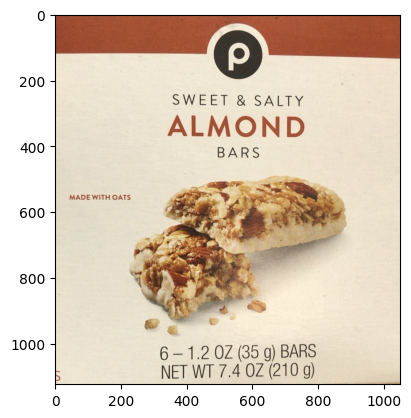

In [89]:
img = mpimg.imread(f'{OUTPUT_DIR}/{image_files[0]}')

# View the image with axes
plt.imshow(img)
plt.show()

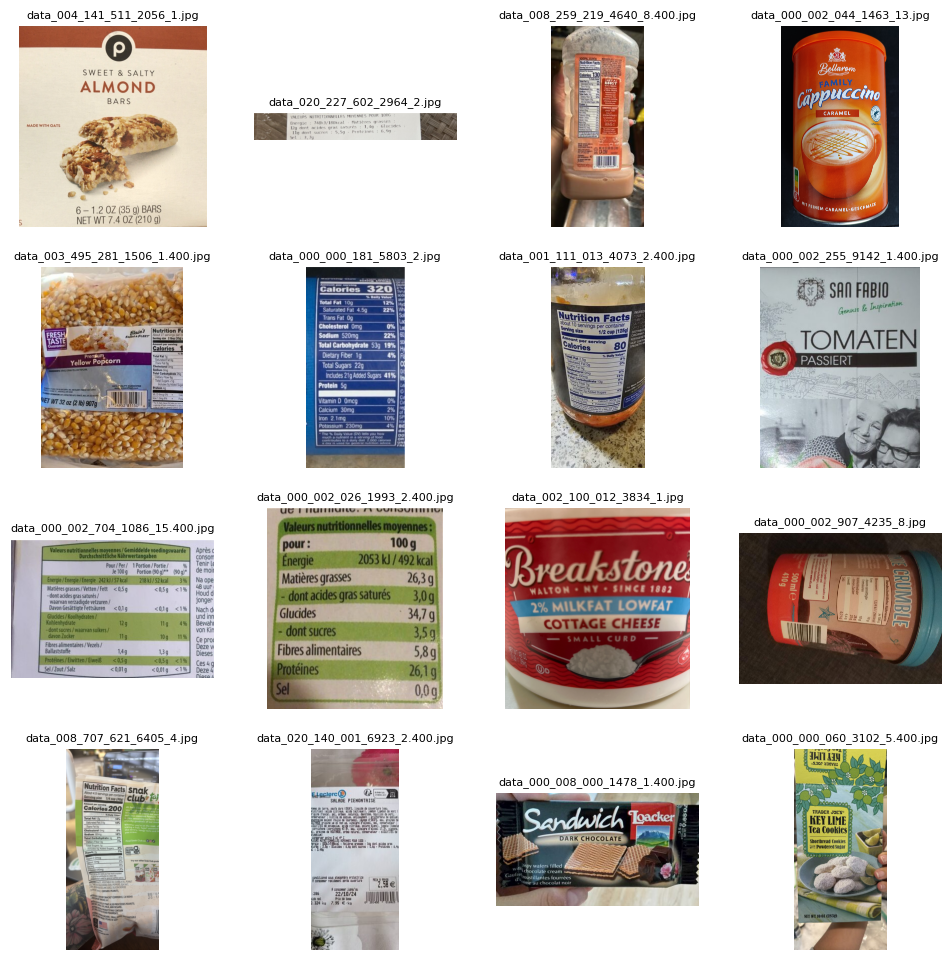

In [114]:
plt.figure(figsize=(12, 12))
for i, img in enumerate(image_files):
    image = mpimg.imread(f'{OUTPUT_DIR}/{img}')
    plt.subplot(4, 4, i + 1)
    plt.imshow(image)
    plt.title(img, fontsize=8)
    plt.axis('off') 
plt.show()

# Open Food Fact Product Data

https://github.com/openfoodfacts/openfoodfacts-python

https://world.openfoodfacts.org/data

#### available product attributes

In [136]:
url = "https://world.openfoodfacts.org/api/v4/attribute_groups"

In [137]:
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36'}
response = requests.get(url, headers=headers)
# response = requests.get(url, timeout=30)

In [138]:
data = response.json()

In [145]:
data[0]

{'attributes': [{'default': 'very_important',
   'icon_url': 'https://static.openfoodfacts.org/images/attributes/dist/nutriscore-a.svg',
   'id': 'nutriscore',
   'name': 'Nutri-Score',
   'panel_id': 'nutriscore',
   'setting_name': 'Good nutritional quality (Nutri-Score)',
   'setting_note': 'The Nutri-Score is computed and can be taken into account for all products, even if is not displayed on the packaging.',
   'values': ['not_important', 'important', 'very_important', 'mandatory']},
  {'icon_url': 'https://static.openfoodfacts.org/images/attributes/dist/nutrient-level-salt-low.svg',
   'id': 'low_salt',
   'name': 'Salt',
   'setting_name': 'Salt in low quantity',
   'setting_note': 'The salt level is taken into account by the Nutri-Score. Use this setting only if you are specifically on a low salt diet.',
   'values': ['not_important', 'important', 'very_important', 'mandatory']},
  {'icon_url': 'https://static.openfoodfacts.org/images/attributes/dist/nutrient-level-sugars-low.s

In [146]:
product_att_df = pd.json_normalize(
    data, 
    record_path='attributes', 
    meta=['id', 'name', 'warning'], 
    meta_prefix='group_',    
    errors='ignore'           
)

In [169]:
product_att_df

,default,icon_url,id,name,panel_id,setting_name,setting_note,values,parameters,description,description_short,group_id,group_name,group_warning
0,very_important,https://static.openfoodfacts.org/images/attrib...,nutriscore,Nutri-Score,nutriscore,Good nutritional quality (Nutri-Score),The Nutri-Score is computed and can be taken i...,"[not_important, important, very_important, man...",NaN,NaN,NaN,nutritional_quality,Nutritional quality,NaN
1,NaN,https://static.openfoodfacts.org/images/attrib...,low_salt,Salt,NaN,Salt in low quantity,The salt level is taken into account by the Nu...,"[not_important, important, very_important, man...",NaN,NaN,NaN,nutritional_quality,Nutritional quality,NaN
2,NaN,https://static.openfoodfacts.org/images/attrib...,low_sugars,Sugars,NaN,Sugars in low quantity,The sugars level is taken into account by the ...,"[not_important, important, very_important, man...",NaN,NaN,NaN,nutritional_quality,Nutritional quality,NaN
3,NaN,https://static.openfoodfacts.org/images/attrib...,low_fat,Fat,NaN,Fat in low quantity,The fat level is taken into account by the Nut...,"[not_important, important, very_important, man...",NaN,NaN,NaN,nutritional_quality,Nutritional quality,NaN
4,NaN,https://static.openfoodfacts.org/images/attrib...,low_saturated_fat,Saturated fat,NaN,Saturated fat in low quantity,The saturated fat level is taken into account ...,"[not_important, important, very_important, man...",NaN,NaN,NaN,nutritional_quality,Nutritional quality,NaN
5,important,https://static.openfoodfacts.org/images/attrib...,nova,NOVA group,nova,No or little food processing (NOVA group),To determine the level of processing of a prod...,"[not_important, important, very_important, man...",NaN,NaN,NaN,processing,Food processing,NaN
6,NaN,https://static.openfoodfacts.org/images/attrib...,additives,Additives,additives,No or few additives,"Additives are markers of food processing, and ...","[not_important, important, very_important, man...",NaN,NaN,NaN,processing,Food processing,NaN
7,NaN,https://static.openfoodfacts.org/images/attrib...,allergens_no_gluten,Gluten,NaN,Without Gluten,NaN,"[not_important, mandatory]",NaN,NaN,NaN,allergens,Allergens,There is always a possibility that data about ...
8,NaN,https://static.openfoodfacts.org/images/attrib...,allergens_no_milk,Milk,NaN,Without Milk,NaN,"[not_important, mandatory]",NaN,NaN,NaN,allergens,Allergens,There is always a possibility that data about ...
9,NaN,https://static.openfoodfacts.org/images/attrib...,allergens_no_eggs,Eggs,NaN,Without Eggs,NaN,"[not_important, mandatory]",NaN,NaN,NaN,allergens,Allergens,There is always a possibility that data about ...


#### OpenFoodFacts Python SDK

In [150]:
api = openfoodfacts.API(user_agent="TestApp/1.0")


In [153]:
code = "0041415112056"
test = api.product.get(code)

In [155]:
test

{'_id': '0041415112056',
 '_keywords': ['almond', 'and', 'bar', 'publix', 'salty', 'sweet'],
 'added_countries_tags': [],
 'allergens': '',
 'allergens_from_ingredients': '',
 'allergens_from_user': '(fr) ',
 'allergens_hierarchy': [],
 'allergens_tags': [],
 'brands': 'Publix',
 'brands_old': 'Publix',
 'brands_tags': ['publix'],
 'categories_properties': {},
 'categories_properties_tags': ['all-products',
  'categories-unknown',
  'agribalyse-food-code-unknown',
  'agribalyse-proxy-food-code-unknown',
  'ciqual-food-code-unknown',
  'agribalyse-unknown'],
 'checkers_tags': [],
 'code': '0041415112056',
 'codes_tags': ['code-13',
  'conflict-with-upc-12',
  '0041415112xxx',
  '004141511xxxx',
  '00414151xxxxx',
  '0041415xxxxxx',
  '004141xxxxxxx',
  '00414xxxxxxxx',
  '0041xxxxxxxxx',
  '004xxxxxxxxxx',
  '00xxxxxxxxxxx',
  '0xxxxxxxxxxxx'],
 'complete': 0,
 'completeness': 0.375,
 'correctors_tags': [],
 'countries': 'en:france',
 'countries_hierarchy': ['en:france'],
 'countries_ta

# USDA FoodData Center

In [171]:
df1 = pd.read_csv("USDA/branded_food.csv")
df1.head()

/var/folders/38/91j125nd24l4xn_f9n7vl8p80000gn/T/ipykernel_66036/1408413521.py:1: DtypeWarning: Columns (2,3,4,6,12,16,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("USDA/branded_food.csv")


,fdc_id,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,not_a_significant_source_of,serving_size,serving_size_unit,household_serving_fulltext,branded_food_category,data_source,package_weight,modified_date,available_date,market_country,discontinued_date,preparation_state_code,trade_channel,short_description,material_code
0,1105904,Richardson Oilseed Products (US) Limited,NaN,NaN,27000612323,Vegetable Oil,NaN,15.0,ml,1 Tbsp (15 ml),Oils Edible,GDSN,NaN,2020-10-02,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
1,1105905,CAMPBELL SOUP COMPANY,NaN,NaN,51000198808,"INGREDIENTS: BEEF STOCK, CONTAINS LESS THAN 2%...",NaN,240.0,ml,Amount per serving,Herbs/Spices/Extracts,GDSN,NaN,2020-09-12,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
2,1105906,CAMPBELL SOUP COMPANY,NaN,NaN,51000213273,"INGREDIENTS: CLAM STOCK, POTATOES, CLAMS, CREA...",NaN,440.0,g,PER CONTAINER,Prepared Soups,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
3,1105907,CAMPBELL SOUP COMPANY,NaN,NaN,51000213303,"INGREDIENTS: WATER, CREAM, BROCCOLI, CELERY, V...",NaN,440.0,g,PER CONTAINER,Prepared Soups,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
4,1105908,CAMPBELL SOUP COMPANY,NaN,NaN,51000224637,"INGREDIENTS: CHICKEN STOCK, CONTAINS LESS THAN...",NaN,240.0,ml,Amount per Serving,Herbs/Spices/Extracts,GDSN,NaN,2020-10-03,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN


In [172]:
df2 = pd.read_csv("USDA/food_nutrient.csv")
df2.head()

,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,13706927,1105904,1257,0.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN
1,13706930,1105904,1293,53.33,NaN,71.0,NaN,NaN,NaN,NaN,NaN
2,13706926,1105904,1253,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN
3,13706921,1105904,1092,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN
4,13706916,1105904,1008,867.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN


In [173]:
df3 = pd.read_csv("USDA/food.csv")
df3.head()

/var/folders/38/91j125nd24l4xn_f9n7vl8p80000gn/T/ipykernel_66036/1059433408.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv("USDA/food.csv")


,fdc_id,data_type,description,food_category_id,publication_date,market_country,trade_channel,microbe_data
0,1105904,branded_food,WESSON Vegetable Oil 1 GAL,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
1,1105905,branded_food,SWANSON BROTH BEEF,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
2,1105906,branded_food,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
3,1105907,branded_food,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
4,1105908,branded_food,SWANSON BROTH CHICKEN,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."


# Data Mapping - USDA and Open Food

In [36]:
use_cols = ['code','url','product_name','abbreviated_product_name','generic_name','quantity','packaging','packaging_tags',	'packaging_en',	'packaging_text',	'brands',	'brands_tags',	'brands_en',	'categories','categories_tags','categories_en','origins',	'origins_tags',	'origins_en','manufacturing_places',	'manufacturing_places_tags',	'labels',	'labels_tags',	'labels_en','ingredients_text',	'ingredients_tags',	'ingredients_analysis_tags',	'allergens',	'allergens_en',	'traces',	'traces_tags',	'traces_en',	'serving_size',	'serving_quantity',	'no_nutrition_data',	'additives_n',	'additives',	'additives_tags',	'additives_en',	'nutriscore_score',	'nutriscore_grade',	'food_groups',	'food_groups_tags',	'food_groups_en','product_quantity','popularity_tags','completeness','main_category',	'main_category_en']

chunk_iter = pd.read_csv(
    "en.openfoodfacts.org.products.csv",
    sep="\t",
    engine="python",
    quoting=csv.QUOTE_NONE,
    on_bad_lines="skip",
    chunksize=100000,
    usecols=use_cols,
    dtype=str  
)

all_chunks = []

for chunk in chunk_iter:
    # chunk = chunk.dropna(subset=["brands"])

    chunk["code"] = chunk["code"].str.zfill(13)

    all_chunks.append(chunk)

df_total = pd.concat(all_chunks, axis=0, ignore_index=True)

print(f"Final dataset contains {len(df_total)} rows.")
df_total.head()


Final dataset contains 4511695 rows.


,code,url,product_name,abbreviated_product_name,generic_name,quantity,packaging,packaging_tags,packaging_en,packaging_text,brands,brands_tags,brands_en,categories,categories_tags,categories_en,origins,origins_tags,origins_en,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_en,ingredients_text,ingredients_tags,ingredients_analysis_tags,allergens,allergens_en,traces,traces_tags,traces_en,serving_size,serving_quantity,no_nutrition_data,additives_n,additives,additives_tags,additives_en,nutriscore_score,nutriscore_grade,food_groups,food_groups_tags,food_groups_en,product_quantity,popularity_tags,completeness,main_category,main_category_en
0,0000000000054,http://world-en.openfoodfacts.org/product/0000...,Limonade artisanale a la rose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,0.1625,NaN,NaN
1,0000000000063,http://world-en.openfoodfacts.org/product/0000...,M&amp;M white,NaN,NaN,80 gram,NaN,NaN,NaN,NaN,Fitpiggy,xx:fitpiggy,fitpiggy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Weizenmehl, Rapsöl, Speisesalz, 1,7% Meersalz,...","en:weizenmehl,en:rapsol,en:speisesalz,en:meers...","en:palm-oil-content-unknown,en:vegan-status-un...",NaN,NaN,NaN,NaN,NaN,80 gram,80,NaN,0,NaN,NaN,NaN,NaN,unknown,NaN,NaN,NaN,80,"top-75-percent-scans-2024,top-80-percent-scans...",0.6625,NaN,NaN
2,0000000000114,http://world-en.openfoodfacts.org/product/0000...,Chocolate n3,NaN,NaN,80 g,NaN,NaN,NaN,NaN,Jeff de Bruges,xx:jeff-de-bruges,jeff-de-bruges,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Green Dot,Made in France","en:green-dot,en:made-in-france","Green Dot,Made in France",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,NaN,NaN,NaN,80,"bottom-25-percent-scans-2022,bottom-20-percent...",0.475,NaN,NaN
3,0000000000431,http://world-en.openfoodfacts.org/product/0000...,Pâte de fruits,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,0.1625,NaN,NaN
4,0000000000105,http://world-en.openfoodfacts.org/product/0000...,Paleta gran reserva - Sierra nevada-,NaN,NaN,750ml,NaN,NaN,NaN,NaN,AdvoCare,xx:advocare,advocare,"Bebidas y preparaciones de bebidas, Bebidas","en:beverages-and-beverages-preparations,en:bev...","Beverages and beverages preparations,Beverages",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Thiamin, Biotin, Chromium, Garcinia cambogia f...","en:thiamin,en:biotin,en:vitamins,en:chromium,e...","en:may-contain-palm-oil,en:vegan-status-unknow...",NaN,NaN,NaN,NaN,NaN,5g,5,NaN,2,NaN,"en:e330,en:e955","E330 - Citric acid,E955 - Sucralose",NaN,unknown,en:artificially-sweetened-beverages,"en:beverages,en:artificially-sweetened-beverages","Beverages,Artificially sweetened beverages",750,"top-75-percent-scans-2024,top-80-percent-scans...",0.675,en:beverages,Beverages


In [27]:
df1 = pd.read_csv("USDA/branded_food.csv")
df1["gtin_upc"] = df1["gtin_upc"].astype(str)
df1["gtin_upc"] = df1["gtin_upc"].str.zfill(13)
df1.head()

/var/folders/38/91j125nd24l4xn_f9n7vl8p80000gn/T/ipykernel_1662/2964289661.py:1: DtypeWarning: Columns (2,3,4,6,12,16,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("USDA/branded_food.csv")


,fdc_id,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,not_a_significant_source_of,serving_size,serving_size_unit,household_serving_fulltext,branded_food_category,data_source,package_weight,modified_date,available_date,market_country,discontinued_date,preparation_state_code,trade_channel,short_description,material_code
0,1105904,Richardson Oilseed Products (US) Limited,NaN,NaN,0027000612323,Vegetable Oil,NaN,15.0,ml,1 Tbsp (15 ml),Oils Edible,GDSN,NaN,2020-10-02,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
1,1105905,CAMPBELL SOUP COMPANY,NaN,NaN,0051000198808,"INGREDIENTS: BEEF STOCK, CONTAINS LESS THAN 2%...",NaN,240.0,ml,Amount per serving,Herbs/Spices/Extracts,GDSN,NaN,2020-09-12,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
2,1105906,CAMPBELL SOUP COMPANY,NaN,NaN,0051000213273,"INGREDIENTS: CLAM STOCK, POTATOES, CLAMS, CREA...",NaN,440.0,g,PER CONTAINER,Prepared Soups,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
3,1105907,CAMPBELL SOUP COMPANY,NaN,NaN,0051000213303,"INGREDIENTS: WATER, CREAM, BROCCOLI, CELERY, V...",NaN,440.0,g,PER CONTAINER,Prepared Soups,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
4,1105908,CAMPBELL SOUP COMPANY,NaN,NaN,0051000224637,"INGREDIENTS: CHICKEN STOCK, CONTAINS LESS THAN...",NaN,240.0,ml,Amount per Serving,Herbs/Spices/Extracts,GDSN,NaN,2020-10-03,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN


In [16]:
df2 = pd.read_csv("USDA/food_nutrient.csv")
df2.head()

,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,13706927,1105904,1257,0.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN
1,13706930,1105904,1293,53.33,NaN,71.0,NaN,NaN,NaN,NaN,NaN
2,13706926,1105904,1253,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN
3,13706921,1105904,1092,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN
4,13706916,1105904,1008,867.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN


In [17]:
df3 = pd.read_csv("USDA/food.csv")
df3.head()

/var/folders/38/91j125nd24l4xn_f9n7vl8p80000gn/T/ipykernel_1662/1059433408.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv("USDA/food.csv")


,fdc_id,data_type,description,food_category_id,publication_date,market_country,trade_channel,microbe_data
0,1105904,branded_food,WESSON Vegetable Oil 1 GAL,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
1,1105905,branded_food,SWANSON BROTH BEEF,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
2,1105906,branded_food,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
3,1105907,branded_food,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
4,1105908,branded_food,SWANSON BROTH CHICKEN,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."


In [18]:
df4 = pd.read_csv("USDA/nutrient.csv")
df4.head()

,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0
3,1002,Nitrogen,G,202.0,500.0
4,1003,Protein,G,203.0,600.0


In [19]:
df5 = pd.read_csv("USDA/microbe.csv")
df5.head()

,id,foodId,method,microbe_code,min_value,max_value,uom
0,1,2331974,AEROBIC_PLATE_COUNT,LACTICASEIBACILLUS_PARACASEI,10000000,NaN,NaN
1,2,2332523,AEROBIC_PLATE_COUNT,LACTICASEIBACILLUS_PARACASEI,10000000,NaN,NaN
2,3,2336972,AEROBIC_PLATE_COUNT,LACTICASEIBACILLUS_PARACASEI,10000000,NaN,X_CFG
3,4,2337521,AEROBIC_PLATE_COUNT,LACTICASEIBACILLUS_PARACASEI,10000000,NaN,X_CFG
4,5,2364024,AEROBIC_PLATE_COUNT,LACTICASEIBACILLUS_PARACASEI,10000000,NaN,X_CFG


In [20]:
df6 = pd.read_csv("USDA/measure_unit.csv")
df6.head()

,id,name
0,1000,cup
1,1001,tablespoon
2,1002,teaspoon
3,1003,liter
4,1004,milliliter


In [21]:
df7 = pd.read_csv("USDA/food_update_log_entry.csv")
df7.head()

,id,description,last_updated
0,1105904,WESSON Vegetable Oil 1 GAL,2020-11-13
1,1105905,SWANSON BROTH BEEF,2020-11-13
2,1105906,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,2020-11-13
3,1105907,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,2020-11-13
4,1105908,SWANSON BROTH CHICKEN,2020-11-13


In [23]:
df8 = pd.read_csv("USDA/food_attribute.csv")
df8.head()

,id,fdc_id,seq_num,food_attribute_type_id,name,value
0,1009437,1105904,NaN,NaN,Ingredients,3
1,1009439,1105905,NaN,NaN,Ingredients,3
2,1009438,1105905,NaN,NaN,Nutrient Removed,6
3,1009440,1105905,NaN,NaN,Nutrient Updated,4
4,1009442,1105906,NaN,NaN,Nutrient Updated,4


In [24]:
df9 = pd.read_csv("USDA/food_attribute_type.csv")
df9.head()

,id,name,description
0,998,Update Log,Changes that were made to this food
1,999,Attribute,Generic attributes
2,1000,Common Name,Common names associated with a food.
3,1001,Additional Description,Additional descriptions for the food.
4,1002,Adjustments,"Adjustments made to foods, including moisture ..."


In [25]:
df10 = pd.read_excel('USDA/Download API Field Descriptions.xlsx')
df10.head()

,FoodData Central Download Field Descriptions,Unnamed: 1,Unnamed: 2
0,NaN,NaN,NaN
1,Guide to tabs,NaN,NaN
2,NaN,Download Field Descriptions,Download Descriptions (contains 1 line for eac...
3,NaN,FNDDS crosswalk,Documentation on what FDC fields the FNDDS dat...


### Data Joins

In [37]:
matched_df = pd.merge(df_total, df1, left_on='code', right_on='gtin_upc', how='inner')


In [40]:
len(df1)

1999950

In [38]:
print(f'Length of merged data: {len(matched_df)}')
print(f'Number of records lost from Open Food Facts: {len(df_total)-len(matched_df)}')
print(f'Number of records lost from USDA Branded Foods: {len(df1)-len(matched_df)}')

Length of merged data: 1743097
Number of records lost from Open Food Facts: 2768598
Number of records lost from USDA Branded Foods: 256853


In [31]:
# print(f'Length of merged data: {len(matched_df)}')
# print(f'Number of records lost from Open Food Facts: {len(df_total)-len(matched_df)}')
# print(f'Number of records lost from USDA Branded Foods: {len(df1)-len(matched_df)}')

Length of merged data: 1082894
Number of records lost from Open Food Facts: 1750285
Number of records lost from USDA Branded Foods: 917056


In [32]:
matched_slim_df = matched_df[['code',	'url',	'product_name','brands', 'categories', 'labels', 'ingredients_text', 'labels', 'ingredients_tags','fdc_id',	'brand_owner',	'brand_name',	'subbrand_name',	'gtin_upc',	'ingredients']]

In [35]:
matched_slim_df.tail(3)

,code,url,product_name,brands,categories,labels,ingredients_text,labels,ingredients_tags,fdc_id,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients
1082891,0000096133262,http://world-en.openfoodfacts.org/product/9613...,Dairy milk wholenut,Cadbury,"Snacks, Sweet snacks, Confectioneries",NaN,"milk**, sugar, cocoa butter, roasted hazelnuts...",NaN,"en:milk,en:dairy,en:sugar,en:added-sugar,en:di...",769934,NaN,NaN,NaN,0000096133262,"Ingredients: MILK**, sugar, cocoa butter, roas..."
1082892,0000096139448,http://world-en.openfoodfacts.org/product/9613...,Cadbury chocolate hollow figure,Cadbury,"Snacks, Sweet snacks, Confectioneries",NaN,"MILK**, sugar, cocoa butter, cocoa mass, veget...",NaN,"en:milk,en:dairy,en:sugar,en:added-sugar,en:di...",770616,NaN,NaN,NaN,0000096139448,"Ingredients: MILK**, sugar, cocoa butter, coco..."
1082893,9644000330654,http://world-en.openfoodfacts.org/product/9644...,"Monari fererzoni, balsamic vinegar of modena g...",Monari Fererzoni,"Condiments, Sauces, Vinegars, Balsamic vinegar...",NaN,"Concentrated grape-juice, balsamic vinegar of ...",NaN,"en:concentrated-grape-juice,en:fruit,en:berrie...",465742,MONARI FERERZONI,NaN,NaN,9644000330654,"CONCENTRATED GRAPE-JUICE, BALSAMIC VINEGAR OF ..."


# EDA

#### Open Food Facts Data

Image Meta Data

In [3]:
# Note: This is not all images... should just connect to AWS S3 bucket rather than storing all images in a new bucket.
image_meta_df = pd.read_csv('image_meta_all.csv')
image_meta_df = image_meta_df[['Key',	'LastModified',	'ETag',	'Size',	'StorageClass',	'ChecksumAlgorithm',	'ChecksumType']]
print(f"Total image dataset contains {len(image_meta_df)} rows.")

Total image dataset contains 19668000 rows.


In [46]:
image_meta_df.tail()

,Key,LastModified,ETag,Size,StorageClass,ChecksumAlgorithm,ChecksumType
19667995,data/848/002/481/9369/1.jpg,2023-04-16 15:16:01+00:00,"""e607e3e4f5c53009288152fc5dd47def""",274874,INTELLIGENT_TIERING,NaN,NaN
19667996,data/848/002/481/9369/1.json.gz,2025-12-21 21:50:04+00:00,"""d4d3bad63455d1bada010c7a411c977a""",5624,STANDARD,['CRC64NVME'],FULL_OBJECT
19667997,data/848/002/481/9383/1.400.jpg,2023-04-15 05:38:10+00:00,"""b5460e2714e318fac971b0073764ed41""",25731,STANDARD,NaN,NaN
19667998,data/848/002/481/9383/1.jpg,2023-04-15 05:38:10+00:00,"""f513a21eacb15a3e044172fc9486a953""",253812,INTELLIGENT_TIERING,NaN,NaN
19667999,data/848/002/481/9383/1.json.gz,2025-12-20 10:37:25+00:00,"""eda047a3b2da78faf2bdfd90a5f28298""",4672,STANDARD,['CRC64NVME'],FULL_OBJECT


Product Data

In [4]:
use_cols = ['code','url','product_name','abbreviated_product_name','generic_name','quantity','packaging','packaging_tags',	'packaging_en',	'packaging_text',	'brands',	'brands_tags',	'brands_en',	'categories','categories_tags','categories_en','origins',	'origins_tags',	'origins_en','manufacturing_places',	'manufacturing_places_tags',	'labels',	'labels_tags',	'labels_en','ingredients_text',	'ingredients_tags',	'ingredients_analysis_tags',	'allergens',	'allergens_en',	'traces',	'traces_tags',	'traces_en',	'serving_size',	'serving_quantity',	'no_nutrition_data',	'additives_n',	'additives',	'additives_tags',	'additives_en',	'nutriscore_score',	'nutriscore_grade',	'food_groups',	'food_groups_tags',	'food_groups_en','product_quantity','popularity_tags','completeness','main_category',	'main_category_en']

In [5]:
chunk_iter = pd.read_csv(
    "en.openfoodfacts.org.products.csv",
    sep="\t",
    engine="python",
    quoting=csv.QUOTE_NONE,
    on_bad_lines="skip",
    chunksize=100000,
    dtype=str  
)

all_chunks = []

for chunk in chunk_iter:
    # chunk = chunk.dropna(subset=["brands"])

    chunk["code"] = chunk["code"].str.zfill(14)

    all_chunks.append(chunk)

product_df_total = pd.concat(all_chunks, axis=0, ignore_index=True)

print(f"Total Product dataset contains {len(product_df_total)} rows.")

Total Product dataset contains 4511695 rows.


In [49]:
product_df_total.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,product_name,abbreviated_product_name,generic_name,quantity,packaging,packaging_tags,packaging_en,packaging_text,brands,brands_tags,brands_en,categories,categories_tags,categories_en,origins,origins_tags,origins_en,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_en,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_en,ingredients_text,ingredients_tags,ingredients_analysis_tags,allergens,allergens_en,traces,traces_tags,traces_en,serving_size,serving_quantity,no_nutrition_data,additives_n,additives,additives_tags,additives_en,nutriscore_score,nutriscore_grade,nova_group,pnns_groups_1,pnns_groups_2,food_groups,food_groups_tags,food_groups_en,states,states_tags,states_en,brand_owner,environmental_score_score,environmental_score_grade,nutrient_levels_tags,product_quantity,owner,data_quality_errors_tags,unique_scans_n,popularity_tags,completeness,last_image_t,last_image_datetime,main_category,main_category_en,image_url,image_small_url,image_ingredients_url,image_ingredients_small_url,image_nutrition_url,image_nutrition_small_url,energy-kj_100g,energy-kcal_100g,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,unsaturated-fat_100g,monounsaturated-fat_100g,omega-9-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,omega-6-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,added-sugars_100g,sucrose_100g,glucose_100g,fructose_100g,galactose_100g,lactose_100g,maltose_100g,maltodextrins_100g,psicose_100g,starch_100g,polyols_100g,erythritol_100g,isomalt_100g,maltitol_100g,sorbitol_100g,fiber_100g,soluble-fiber_100g,polydextrose_100g,insoluble-fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,added-salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,methylsulfonylmethane_100g,hydroxymethylbutyrate_100g,ph_100g,fruits-vegetables-legumes_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,glycemic-index_100g,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,00000000000054,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1740205422,2025-02-22T06:23:42Z,Limonade artisanale a la rose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en:fr,en:france,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,NaN,unknown,unknown,NaN,NaN,NaN,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","To be completed,Nutrition facts to be complete...",NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,0.1625,173308

Images

In [54]:
# re_json: captures the filename before .json.gz (optional, usually just '1', '2', etc.)
re_json = re.compile(r'/([^/]+)\.json\.gz$')

# re_resized: captures the size (e.g., 100, 400, full)
re_resized = re.compile(r'\.([^.]+)\.jpg$')

# re_original: captures the digit before .jpg (e.g., 1, 2, 13)
re_original = re.compile(r'/(\d+)\.jpg$')

file_groups = defaultdict(list)

# Iterating through your DataFrame
for i, row in image_meta_df.iterrows():
    key = row['Key']
    
    # 1. Categorize Metadata (Subgroups by file number/name)
    json_match = re_json.search(key)
    if json_match:
        subgroup = json_match.group(1) # This gets '1' from '1.json.gz'
        file_groups[f'metadata_json_{subgroup}'].append(key)
        continue # Move to next row

    # 2. Categorize Resized (Subgroups by size: 100, 400, full)
    resized_match = re_resized.search(key)
    if resized_match:
        size = resized_match.group(1) # This gets '400' from '1.400.jpg'
        file_groups[f'resized_{size}'].append(key)
        continue

    # 3. Categorize Originals (Subgroups by index: 1, 2, 3...)
    original_match = re_original.search(key)
    if original_match:
        index = original_match.group(1) # This gets '1' from '/1.jpg'
        file_groups[f'originals_{index}'].append(key)
        continue
    
    # 4. Catch-all for "Discovery" (Anything that didn't match the above)
    file_groups['unclassified'].append(key)

In [60]:
# OUTPUT_DIR = "off_sample"
# BASE_URL = "https://openfoodfacts-images.s3.eu-west-3.amazonaws.com/"

# # 1. Collect 5 random samples from every subgroup
# # We store them as (category, key) pairs to keep track of folder mapping
# samples_to_download = []

# for category, keys in file_groups.items():
#     num_to_sample = min(len(keys), 5)
#     group_samples = random.sample(keys, num_to_sample)
    
#     for key in group_samples:
#         samples_to_download.append((category, key))

# print(f"Prepared {len(samples_to_download)} downloads across {len(file_groups)} categories.")

# # 2. Download and Organize
# for category, key in tqdm(samples_to_download, desc="Downloading samples"):
#     # Create the category-specific subfolder
#     cat_dir = os.path.join(OUTPUT_DIR, category)
#     os.makedirs(cat_dir, exist_ok=True)
    
#     # Define the download URL and local save path
#     url = BASE_URL + key
#     # We still flatten the key for the filename to ensure it's unique within the subfolder
#     filename = key.replace("/", "_")
#     save_path = os.path.join(cat_dir, filename)

#     # Skip if already exists
#     if os.path.exists(save_path):
#         continue

#     try:
#         # Use stream=True for memory efficiency
#         r = requests.get(url, timeout=30, stream=True)

#         if r.status_code == 200:
#             with open(save_path, "wb") as f:
#                 for chunk in r.iter_content(chunk_size=8192):
#                     f.write(chunk)
#         else:
#             # Handle cases where the S3 object might be indexed but missing
#             with open("download_errors.log", "a") as log:
#                 log.write(f"Failed: {url} | Status: {r.status_code}\n")

#     except Exception as e:
#         with open("download_errors.log", "a") as log:
#             log.write(f"Error: {url} | Exception: {str(e)}\n")

# print(f"\nFinished! Check the '{OUTPUT_DIR}' directory for your organized samples.")

Prepared 3826 downloads across 1151 categories.



Finished! Check the 'off_sample' directory for your organized samples.


In [29]:
# 1. Regex patterns to recreate the category folders used in sampling
re_json = re.compile(r'/([^/]+)\.json\.gz$')
re_resized = re.compile(r'\.([^.]+)\.jpg$')
re_original = re.compile(r'/(\d+)\.jpg$')

def get_category(key):
    """Replicates the folder naming logic from the download step."""
    json_match = re_json.search(key)
    if json_match:
        return f'metadata_json_{json_match.group(1)}'
    
    resized_match = re_resized.search(key)
    if resized_match:
        return f'resized_{resized_match.group(1)}'
    
    original_match = re_original.search(key)
    if original_match:
        return f'originals_{original_match.group(1)}'
    
    return 'unclassified'

def extract_barcode_14(key):
    """Joins segments and pads to exactly 14 digits."""
    parts = key.split('/')
    if len(parts) >= 5:
        # Concatenate indices 1, 2, 3, and 4 (e.g., 848 + 002 + 481 + 9369)
        barcode = "".join(parts[1:5])
        return barcode.zfill(14)
    return None

# --- Apply Transformations ---

# Create the 14-digit barcode column
image_meta_df['code'] = image_meta_df['Key'].apply(extract_barcode_14)

# Define the root directory where samples were stored
OUTPUT_DIR = "off_sample"

def find_local_storage(row):
    """Constructs the path and checks if it was one of the downloaded samples."""
    key = row['Key']
    category = get_category(key)
    filename = key.replace("/", "_") # Replicate the 'flattening' logic
    
    local_path = os.path.join(OUTPUT_DIR, category, filename)
    
    # If the file exists in our local folder, it was part of the download
    if os.path.exists(local_path):
        return local_path
    return "N/A"

# Add the storage location column
image_meta_df['local_storage_location'] = image_meta_df.apply(find_local_storage, axis=1)

In [30]:
print(len(image_meta_df))
image_meta_df.head(15)

19668000


Traceback (most recent call last):
  File "/Users/stevenlanciotti/Working_Desktop/DataSci_210/OpenFoodFacts/.venv/lib/python3.9/site-packages/IPython/core/completer.py", line 3171, in _complete
    result = matcher(context)
  File "/Users/stevenlanciotti/Working_Desktop/DataSci_210/OpenFoodFacts/.venv/lib/python3.9/site-packages/IPython/core/completer.py", line 2099, in magic_matcher
    matches = self.magic_matches(text)
  File "/Users/stevenlanciotti/Working_Desktop/DataSci_210/OpenFoodFacts/.venv/lib/python3.9/site-packages/IPython/core/completer.py", line 2132, in magic_matches
    global_matches = self.global_matches(bare_text)
  File "/Users/stevenlanciotti/Working_Desktop/DataSci_210/OpenFoodFacts/.venv/lib/python3.9/site-packages/IPython/core/completer.py", line 1113, in global_matches
    for word in lst:
RuntimeError: dictionary changed size during iteration


,Key,LastModified,ETag,Size,StorageClass,ChecksumAlgorithm,ChecksumType,code,local_storage_location
0,README.md,2023-05-13 10:00:29+00:00,"""059e12e58791699f80921f4275f3dc8e""",1849,STANDARD,NaN,NaN,None,off_sample/unclassified/README.md
1,data/000/000/000/0000/1.400.jpg,2026-01-03 15:50:02+00:00,"""96b9832dc3bcbd8e998249fe80c7e2be""",25976,STANDARD,['CRC64NVME'],FULL_OBJECT,00000000000000,N/A
2,data/000/000/000/0000/1.jpg,2026-01-03 15:50:02+00:00,"""4542121be1c76c428202528f133b9dbb""",134484,INTELLIGENT_TIERING,['CRC64NVME'],FULL_OBJECT,00000000000000,N/A
3,data/000/000/000/0000/1.json.gz,2026-01-03 15:50:02+00:00,"""de8f5947d1037f1d6c826c5449cf19f7""",408,STANDARD,['CRC64NVME'],FULL_OBJECT,00000000000000,N/A
4,data/000/000/000/0000/10.400.jpg,2024-10-16 00:24:44+00:00,"""6d02535f66ebef483fc258440fbe00af""",31967,STANDARD,NaN,NaN,00000000000000,N/A
5,data/000/000/000/0000/10.jpg,2024-10-16 00:24:44+00:00,"""0465f4803a69391e468bf0cd396d4575""",177510,INTELLIGENT_TIERING,NaN,NaN,00000000000000,N/A
6,data/000/000/000/0000/100.400.jpg,2025-08-08 22:04:36+00:00,"""751d7915ca79dfdb9d49d9aa41855245""",26002,STANDARD,['CRC64NVME'],FULL_OBJECT,00000000000000,N/A
7,data/000/000/000/0000/100.jpg,2025-08-08 22:04:35+00:00,"""bdcebf63573fdeb411a28fa9a6002905""",49963,STANDARD,['CRC64NVME'],FULL_OBJECT,00000000000000,N/A
8,data/000/000/000/0000/100.json.gz,2025-08-08 22:04:36+00:00,"""ae6b704f6a7e2c75cc5b4c4a5bcdeccb""",6000,STANDARD,['CRC64NVME'],FULL_OBJECT,00000000000000,N/A
9,data/000/000/000/0000/101.400.jpg,2025-08-08 22:04:47+00:00,"""074b703e79152cd35bf8c503b40fc092""",58240,STANDARD,['CRC64NVME'],FULL_OBJECT,00000000000000,N/A


In [61]:
image_count = pd.pivot_table(image_meta_df,values='Key',index=['code'], aggfunc='count').reset_index()

In [62]:
print(len(image_count))
image_count.head()

3129479


,code,Key
0,00000000000000,451
1,00000000000003,3
2,00000000000007,22
3,00000000000008,37
4,00000000000009,36


#### USDA

Branded Foods

In [6]:
branded_df = pd.read_csv("USDA/branded_food.csv")
branded_df["gtin_upc"] = branded_df["gtin_upc"].astype(str)
branded_df["gtin_upc"] = branded_df["gtin_upc"].str.zfill(14)
branded_df.head()

/var/folders/38/91j125nd24l4xn_f9n7vl8p80000gn/T/ipykernel_75734/2337986689.py:1: DtypeWarning: Columns (2,3,4,6,12,16,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  branded_df = pd.read_csv("USDA/branded_food.csv")


,fdc_id,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,not_a_significant_source_of,serving_size,serving_size_unit,household_serving_fulltext,branded_food_category,data_source,package_weight,modified_date,available_date,market_country,discontinued_date,preparation_state_code,trade_channel,short_description,material_code
0,1105904,Richardson Oilseed Products (US) Limited,NaN,NaN,00027000612323,Vegetable Oil,NaN,15.0,ml,1 Tbsp (15 ml),Oils Edible,GDSN,NaN,2020-10-02,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
1,1105905,CAMPBELL SOUP COMPANY,NaN,NaN,00051000198808,"INGREDIENTS: BEEF STOCK, CONTAINS LESS THAN 2%...",NaN,240.0,ml,Amount per serving,Herbs/Spices/Extracts,GDSN,NaN,2020-09-12,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
2,1105906,CAMPBELL SOUP COMPANY,NaN,NaN,00051000213273,"INGREDIENTS: CLAM STOCK, POTATOES, CLAMS, CREA...",NaN,440.0,g,PER CONTAINER,Prepared Soups,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
3,1105907,CAMPBELL SOUP COMPANY,NaN,NaN,00051000213303,"INGREDIENTS: WATER, CREAM, BROCCOLI, CELERY, V...",NaN,440.0,g,PER CONTAINER,Prepared Soups,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
4,1105908,CAMPBELL SOUP COMPANY,NaN,NaN,00051000224637,"INGREDIENTS: CHICKEN STOCK, CONTAINS LESS THAN...",NaN,240.0,ml,Amount per Serving,Herbs/Spices/Extracts,GDSN,NaN,2020-10-03,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN


Food Nutrient

In [22]:
food_nutrient_df = pd.read_csv("USDA/food_nutrient.csv")
food_nutrient_df.head()

,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,13706927,1105904,1257,0.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN
1,13706930,1105904,1293,53.33,NaN,71.0,NaN,NaN,NaN,NaN,NaN
2,13706926,1105904,1253,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN
3,13706921,1105904,1092,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN
4,13706916,1105904,1008,867.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN


Food

In [7]:
food_df = pd.read_csv("USDA/food.csv")
food_df.head()

/var/folders/38/91j125nd24l4xn_f9n7vl8p80000gn/T/ipykernel_75734/1497250535.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  food_df = pd.read_csv("USDA/food.csv")


,fdc_id,data_type,description,food_category_id,publication_date,market_country,trade_channel,microbe_data
0,1105904,branded_food,WESSON Vegetable Oil 1 GAL,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
1,1105905,branded_food,SWANSON BROTH BEEF,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
2,1105906,branded_food,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
3,1105907,branded_food,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
4,1105908,branded_food,SWANSON BROTH CHICKEN,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."


Nutrient

In [24]:
nutrient_df = pd.read_csv("USDA/nutrient.csv")
nutrient_df.head()

,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0
3,1002,Nitrogen,G,202.0,500.0
4,1003,Protein,G,203.0,600.0


Food Update

In [25]:
food_update_df = pd.read_csv("USDA/food_update_log_entry.csv")
food_update_df.head()

,id,description,last_updated
0,1105904,WESSON Vegetable Oil 1 GAL,2020-11-13
1,1105905,SWANSON BROTH BEEF,2020-11-13
2,1105906,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,2020-11-13
3,1105907,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,2020-11-13
4,1105908,SWANSON BROTH CHICKEN,2020-11-13


Food Attribute

In [26]:
food_attribute_df = pd.read_csv("USDA/food_attribute.csv")
food_attribute_df.head()

,id,fdc_id,seq_num,food_attribute_type_id,name,value
0,1009437,1105904,NaN,NaN,Ingredients,3
1,1009439,1105905,NaN,NaN,Ingredients,3
2,1009438,1105905,NaN,NaN,Nutrient Removed,6
3,1009440,1105905,NaN,NaN,Nutrient Updated,4
4,1009442,1105906,NaN,NaN,Nutrient Updated,4


### Data Analysis

Images

In [2]:
# FORCE inline plotting for VS Code
%matplotlib inline

OUTPUT_DIR = "off_sample"

print("Scanning directories...")
# Simplified scan: just get the names first
all_items = os.listdir(OUTPUT_DIR)
category_folders = [f for f in all_items if f.startswith("originals_")]

# Fast alphabetical sort first to ensure it's not the sorting hanging
category_folders.sort()

print(f"Found {len(category_folders)} 'originals' categories.")

def browse_images(category):
    cat_path = os.path.join(OUTPUT_DIR, category)
    image_files = [f for f in os.listdir(cat_path) if f.lower().endswith(('.jpg', '.jpeg'))]
    
    if not image_files:
        print(f"No images in {category}")
        return

    # Use a smaller figure size initially to speed up rendering
    fig, axes = plt.subplots(1, 5, figsize=(15, 4))
    
    for i in range(5):
        if i < len(image_files):
            try:
                img = mpimg.imread(os.path.join(cat_path, image_files[i]))
                axes[i].imshow(img)
                axes[i].set_title(f"Img {i+1}", fontsize=8)
            except:
                axes[i].text(0.5, 0.5, "Error")
        axes[i].axis('off')
    
    plt.show()

# If you have too many categories, let's limit to the first 100 just to test
test_folders = category_folders[:100]

print("Launching interactive widget...")
# Using a SelectionSlider is often more stable in VS Code than a huge Dropdown
interact(browse_images, category=widgets.SelectionSlider(
    options=category_folders,
    description='Folder:',
    continuous_update=False  # Only updates when you release the slider
));

Scanning directories...
Found 573 'originals' categories.
Launching interactive widget...


interactive(children=(SelectionSlider(continuous_update=False, description='Folder:', options=('originals_1', …

Unique Barcodes

In [10]:
# 1. Define categorization logic (using existing regex)
re_json = re.compile(r'\.json\.gz$')
re_resized = re.compile(r'\.\d+\.jpg$')
re_original = re.compile(r'/\d+\.jpg$')

def get_file_type(key):
    if re_json.search(key):
        return 'json_count'
    if re_resized.search(key):
        return 'resized_count'
    if re_original.search(key):
        return 'original_count'
    return 'other'

# 2. Define barcode extraction logic
def extract_barcode(key):
    # Splits 'data/000/008/000/1478/1.400.jpg' 
    # and joins segments 1, 2, 3, and 4
    parts = key.split('/')
    # if len(parts) >= 5:
    barcode = "".join(parts[1:5])
        # return barcode.zfill(14)
    return barcode.zfill(14)

# 3. Process the DataFrame
# Assuming your source dataframe is named image_meta_df
df_summary = image_meta_df.copy()

print("Extracting barcodes and types...")
df_summary['barcode'] = df_summary['Key'].apply(extract_barcode)
df_summary['type'] = df_summary['Key'].apply(get_file_type)

# 4. Pivot the data to get the counts per barcode
# This creates a table where each row is a barcode and columns are the counts
barcode_df = df_summary.pivot_table(
    index='barcode', 
    columns='type', 
    values='Key', 
    aggfunc='count', 
    fill_value=0
).reset_index()

# 5. Clean up columns
# Ensure all requested columns exist even if some counts are 0
for col in ['original_count', 'resized_count', 'json_count']:
    if col not in barcode_df.columns:
        barcode_df[col] = 0

# Select only the columns you asked for
# barcode_df = barcode_df[['barcode', 'original_count', 'resized_count', 'json_count']]

print(f"Aggregated data for {len(barcode_df)} unique products.")


Extracting barcodes and types...
Aggregated data for 3129479 unique products.


In [11]:
barcode_df.sort_values(by='original_count',inplace=True,ascending=False)
barcode_df.head(100)

type,barcode,json_count,original_count,other,resized_count
733308,00811620022118,378,389,0,375
802770,00856312002757,280,280,0,280
845391,01234567890123,270,272,0,264
76822,00000020036898,246,256,0,242
3088150,08480000141927,252,247,0,244
...,...,...,...,...,...
744275,00818290015631,84,82,0,85
803159,00856461008662,83,81,0,78
1271547,03302748083022,83,81,0,77
732022,00811130034083,88,81,0,80


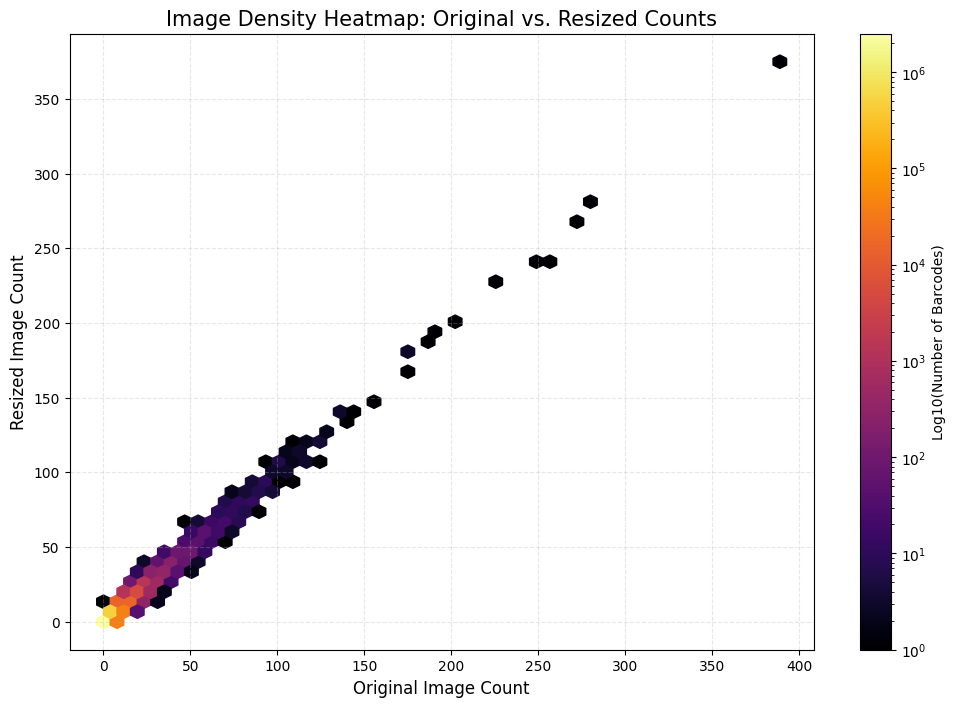

In [8]:
plt.figure(figsize=(12, 8))

# Using log scale for bins because most products have few images, 
# while a few have hundreds.
hb = plt.hexbin(
    barcode_df['original_count'], 
    barcode_df['resized_count'], 
    gridsize=50, 
    cmap='inferno', 
    bins='log'
)

plt.colorbar(hb, label='Log10(Number of Barcodes)')
plt.title('Image Density Heatmap: Original vs. Resized Counts', fontsize=15)
plt.xlabel('Original Image Count', fontsize=12)
plt.ylabel('Resized Image Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

/var/folders/38/91j125nd24l4xn_f9n7vl8p80000gn/T/ipykernel_16687/3561242357.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='original_count', data=df_filtered, palette='viridis')


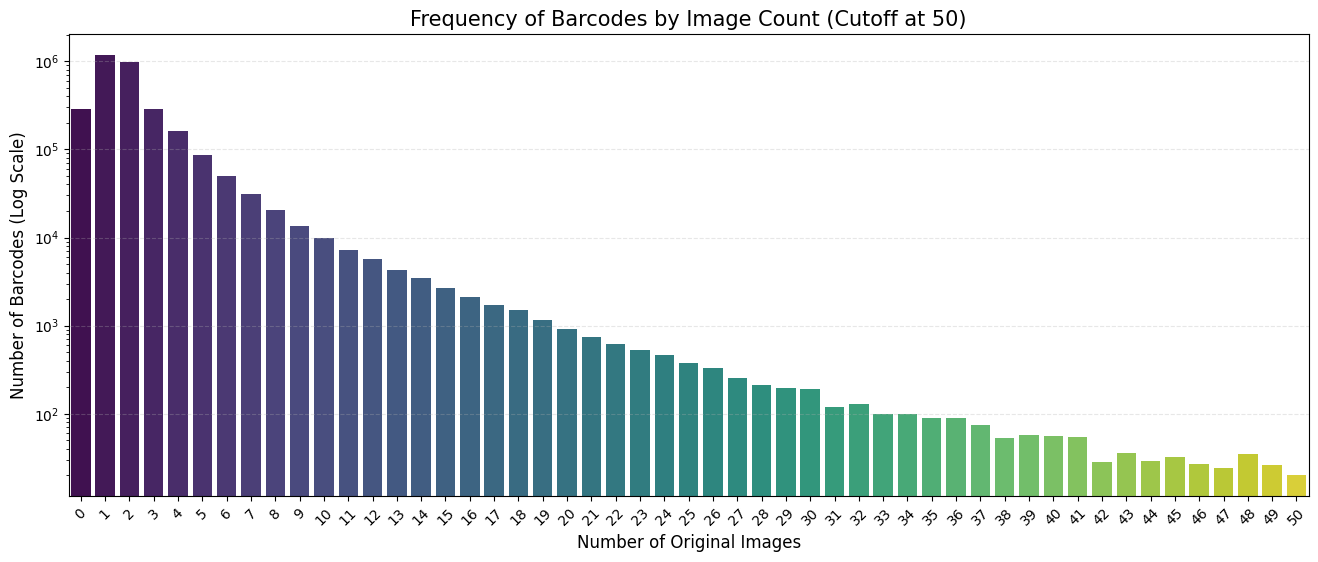

In [19]:
import seaborn as sns

df_filtered = barcode_df[barcode_df['original_count'] <= 50]
plt.figure(figsize=(16, 6))

# 2. Create the Seaborn count plot
sns.countplot(x='original_count', data=df_filtered, palette='viridis')

# 3. Apply Log Scale to handle the massive difference in volume
plt.yscale('log')

# 4. Clean up the labels
plt.title('Frequency of Barcodes by Image Count (Cutoff at 50)', fontsize=15)
plt.xlabel('Number of Original Images', fontsize=12)
plt.ylabel('Number of Barcodes (Log Scale)', fontsize=12)

# Ensure every integer from 0-50 is visible on the x-axis
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

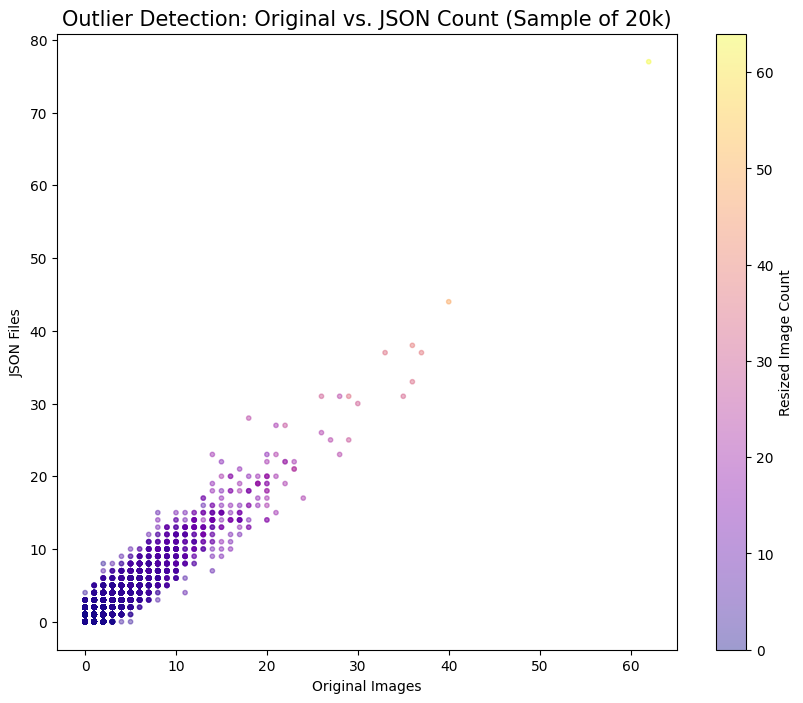

In [14]:
df_sample = barcode_df.sample(20000)

plt.figure(figsize=(10, 8))
plt.scatter(
    df_sample['original_count'], 
    df_sample['json_count'], 
    alpha=0.4,       # Transparency shows overlap
    s=10,            # Small dot size
    c=df_sample['resized_count'], # Color dots by their resized count
    cmap='plasma'
)

plt.colorbar(label='Resized Image Count')
plt.title('Outlier Detection: Original vs. JSON Count (Sample of 20k)', fontsize=15)
plt.xlabel('Original Images')
plt.ylabel('JSON Files')
plt.show()

OFF Products

In [96]:
print(len(product_df_total))
product_df_total.head(2)

4511695


,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,product_name,abbreviated_product_name,generic_name,quantity,packaging,packaging_tags,packaging_en,packaging_text,brands,brands_tags,brands_en,categories,categories_tags,categories_en,origins,origins_tags,origins_en,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_en,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_en,ingredients_text,ingredients_tags,ingredients_analysis_tags,allergens,allergens_en,traces,traces_tags,traces_en,serving_size,serving_quantity,no_nutrition_data,additives_n,additives,additives_tags,additives_en,nutriscore_score,nutriscore_grade,nova_group,pnns_groups_1,pnns_groups_2,food_groups,food_groups_tags,food_groups_en,states,states_tags,states_en,brand_owner,environmental_score_score,environmental_score_grade,nutrient_levels_tags,product_quantity,owner,data_quality_errors_tags,unique_scans_n,popularity_tags,completeness,last_image_t,last_image_datetime,main_category,main_category_en,image_url,image_small_url,image_ingredients_url,image_ingredients_small_url,image_nutrition_url,image_nutrition_small_url,energy-kj_100g,energy-kcal_100g,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,unsaturated-fat_100g,monounsaturated-fat_100g,omega-9-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,omega-6-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,added-sugars_100g,sucrose_100g,glucose_100g,fructose_100g,galactose_100g,lactose_100g,maltose_100g,maltodextrins_100g,psicose_100g,starch_100g,polyols_100g,erythritol_100g,isomalt_100g,maltitol_100g,sorbitol_100g,fiber_100g,soluble-fiber_100g,polydextrose_100g,insoluble-fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,added-salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,methylsulfonylmethane_100g,hydroxymethylbutyrate_100g,ph_100g,fruits-vegetables-legumes_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,glycemic-index_100g,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,00000000000054,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1740205422,2025-02-22T06:23:42Z,Limonade artisanale a la rose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en:fr,en:france,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,NaN,unknown,unknown,NaN,NaN,NaN,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","To be completed,Nutrition facts to be complete...",NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,0.1625,173308

In [68]:
df_unique_products = product_df_total.drop_duplicates(subset=['code'])
print(len(df_unique_products))

4511629


In [69]:
off_product_country = product_df_total.pivot_table(
    index='countries_en', 
    # columns='type', 
    values='code', 
    aggfunc='count', 
    fill_value=0
).reset_index()

In [78]:
off_product_country.sort_values(by='code',ascending=False,inplace=True)

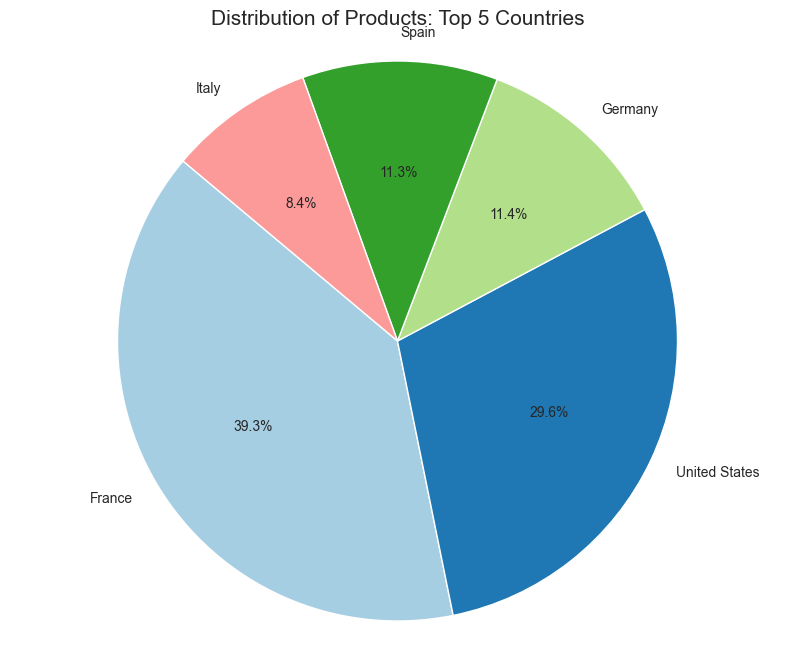

In [81]:
plt.figure(figsize=(10, 8))
plt.pie(
    off_product_country['code'][0:5], 
    labels=off_product_country['countries_en'][0:5], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Paired.colors
)

plt.title('Distribution of Products: Top 5 Countries', fontsize=15)
plt.axis('equal') # Ensures the pie is drawn as a circle

plt.savefig('top_5_countries_pie_chart.png')

/var/folders/38/91j125nd24l4xn_f9n7vl8p80000gn/T/ipykernel_16687/2813815541.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


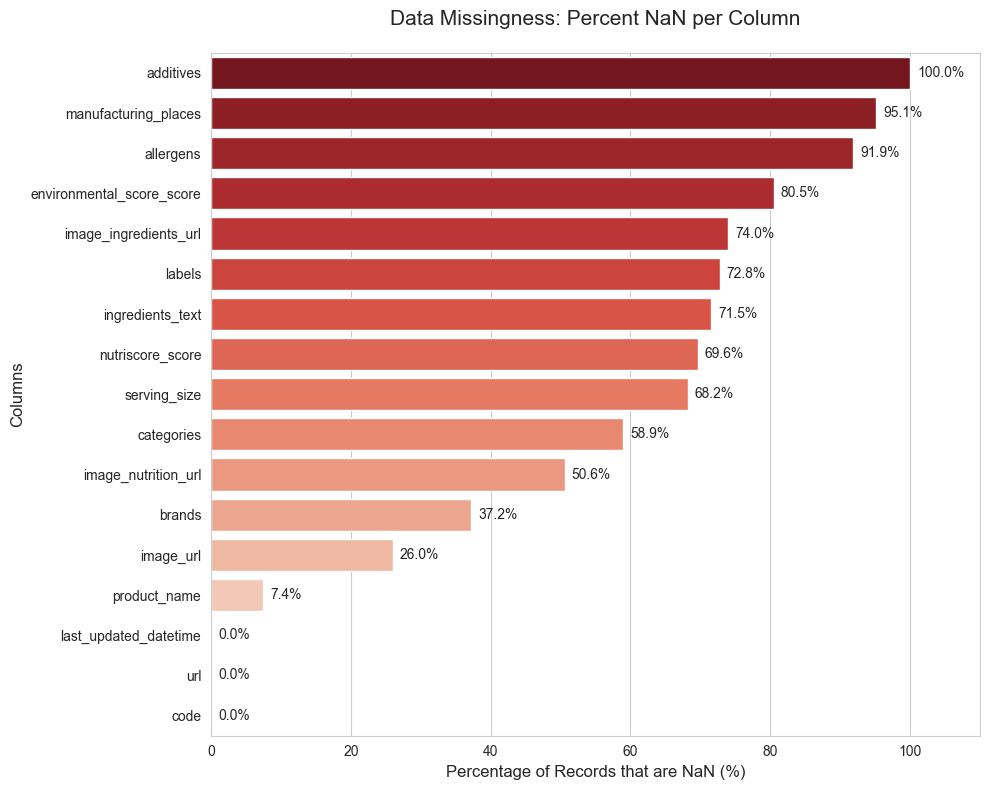

In [74]:
selected_columns = ['code','url','last_updated_datetime','categories','manufacturing_places','labels','ingredients_text','allergens','serving_size','additives',
    'product_name', 'brands', 'nutriscore_score', 'environmental_score_score', 
    'image_url', 'image_ingredients_url', 'image_nutrition_url'
]

# 2. Calculate the percentage of NaNs for these columns
# We multiply by 100 to get the % format
null_percentages = (product_df_total[selected_columns].isnull().sum() / len(product_df_total)) * 100

# 3. Convert to a DataFrame for easier plotting with Seaborn
null_df = null_percentages.reset_index()
null_df.columns = ['Column', 'Percent_NaN']

# 4. Sort by percentage so the chart is a nice "waterfall"
null_df = null_df.sort_values(by='Percent_NaN', ascending=False)

# 5. Create the horizontal bar chart
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Use a color palette that highlights high NaN counts (reds/oranges)
ax = sns.barplot(
    x='Percent_NaN', 
    y='Column', 
    data=null_df, 
    palette='Reds_r'
)

# Add percentage labels to the end of each bar for precision
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 1, p.get_y() + p.get_height()/2 + 0.1, 
            f'{width:.1f}%', ha="left", fontsize=10)

plt.title('Data Missingness: Percent NaN per Column', fontsize=15, pad=20)
plt.xlabel('Percentage of Records that are NaN (%)', fontsize=12)
plt.ylabel('Columns', fontsize=12)
plt.xlim(0, 110) # Leave room for the labels

plt.tight_layout()
plt.show()

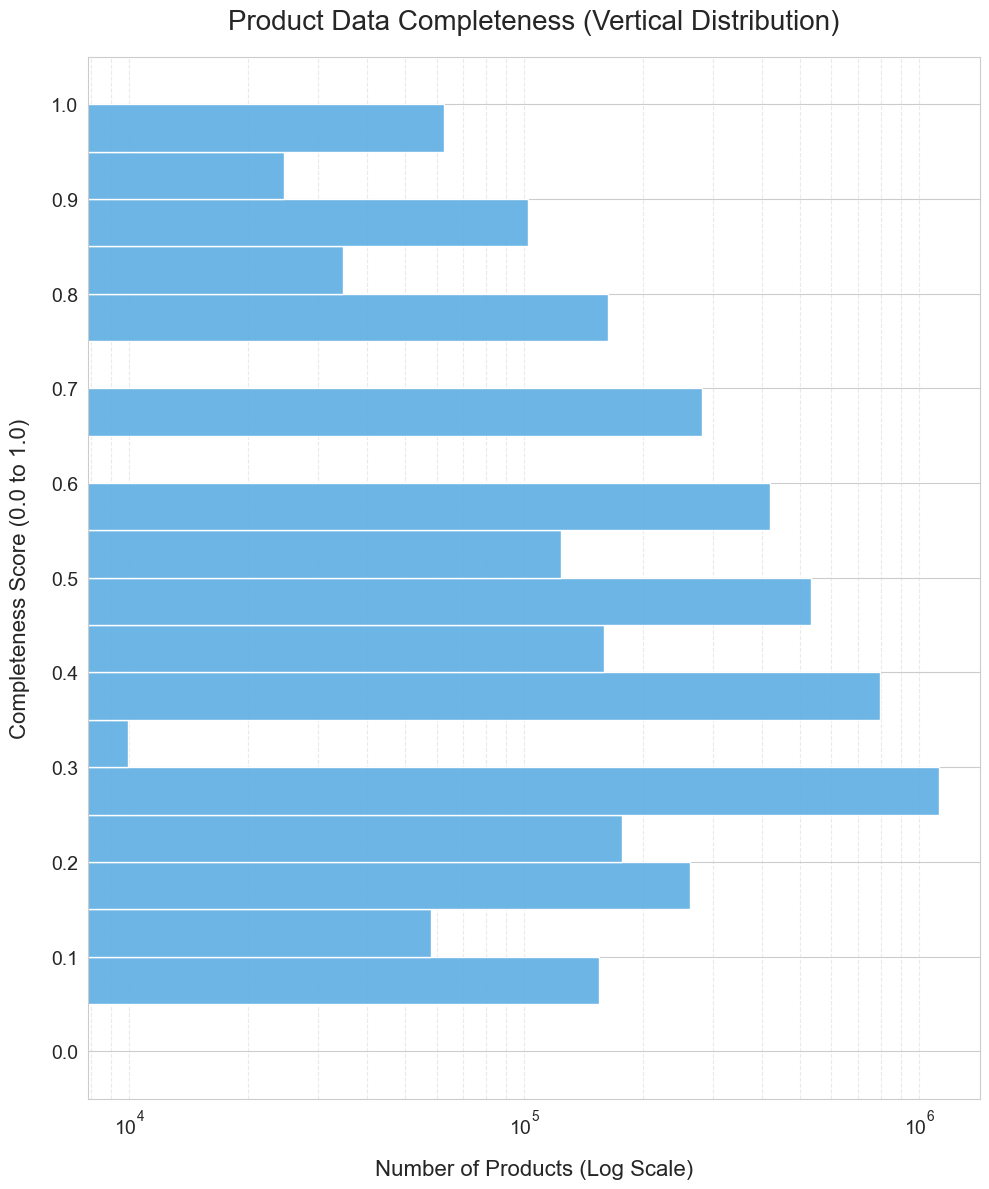

In [89]:
# Ensure data is numeric
product_df_total['completeness'] = pd.to_numeric(product_df_total['completeness'], errors='coerce')

plt.figure(figsize=(10, 12)) # Taller figure for vertical layout

# 1. Note the change from 'x' to 'y'
sns.histplot(
    y=product_df_total['completeness'].dropna(), 
    bins=20, 
    binrange=(0, 1), 
    color='#5dade2',
    edgecolor='white',
    alpha=0.9
)

# Log scale for the count axis
plt.xscale('log')

# --- ADJUSTING FONT SIZES ---

# Y-axis ticks (Completeness Score)
plt.yticks([i/10 for i in range(11)], fontsize=14) 

# X-axis ticks (Log Counts)
# Note: Since it's log scale, we let Matplotlib handle the numbers, 
# but we force the font size.
plt.xticks(fontsize=14)

# Axis Labels
plt.ylabel('Completeness Score (0.0 to 1.0)', fontsize=16, labelpad=15)
plt.xlabel('Number of Products (Log Scale)', fontsize=16, labelpad=15)

# Title
plt.title('Product Data Completeness (Vertical Distribution)', fontsize=20, pad=20)

# --- FINISHING ---
plt.grid(axis='x', linestyle='--', alpha=0.4, which='both')
plt.tight_layout()

plt.show()

Images + Product Names

In [92]:
len(product_df_total.drop_duplicates(subset=['code']))

KeyboardInterrupt: 

In [91]:
len(branded_df.drop_duplicates(subset=['gtin_upc']))

1999950

In [8]:
keep_cols = ['fdc_id',	'brand_owner',	'brand_name','gtin_upc','description','market_country_x','modified_date',	'available_date','publication_date']
merged_USDA_brand_df = pd.merge(branded_df, food_df, left_on='fdc_id', right_on='fdc_id', how='inner')
merged_USDA_brand_df = merged_USDA_brand_df[keep_cols]


In [101]:
print(merged_USDA_brand_df['gtin_upc'].nunique())

442181


In [95]:
print(branded_df['gtin_upc'].nunique())
print(branded_df['fdc_id'].nunique())

442181
1999950


In [102]:
merged_USDA_brand_df.head(2)

,fdc_id,brand_owner,brand_name,gtin_upc,description,market_country_x,modified_date,available_date,publication_date
0,1105904,Richardson Oilseed Products (US) Limited,NaN,00027000612323,WESSON Vegetable Oil 1 GAL,United States,2020-10-02,2020-11-13,2020-11-13
1,1105905,CAMPBELL SOUP COMPANY,NaN,00051000198808,SWANSON BROTH BEEF,United States,2020-09-12,2020-11-13,2020-11-13


In [12]:
keep_cols = ['barcode',	'code',	'url','last_updated_datetime','json_count',	'original_count', 'resized_count','product_name','ingredients_text']
merged_off_df = pd.merge(barcode_df, product_df_total, left_on='barcode', right_on='code', how='inner')
merged_off_df = merged_off_df[keep_cols]

In [14]:
# print(barcode_df['barcode'].nunique())
# print(product_df_total['code'].nunique())
# print(merged_off_df['code'].nunique())
print(len(barcode_df))
print(len(product_df_total))
print(len(merged_off_df))

3129479
4511695
3127139


In [15]:
barcode_product_df = pd.merge(merged_off_df, merged_USDA_brand_df, left_on='barcode', right_on='gtin_upc', how='inner')

barcode_product_df = barcode_product_df[['barcode','code','url','last_updated_datetime','original_count',	'resized_count',	'json_count','product_name','ingredients_text','fdc_id','brand_owner','brand_name','gtin_upc','description','market_country_x']]

In [19]:
barcode_product_df.head()

,barcode,code,url,last_updated_datetime,original_count,resized_count,json_count,product_name,ingredients_text,fdc_id,brand_owner,brand_name,gtin_upc,description,market_country_x
0,00856312002757,00856312002757,http://world-en.openfoodfacts.org/product/0856...,2026-05-12T23:37:35Z,280,280,280,ultra-filtered milk,"ultra filtered milk, lactase enzyme, vitamin A...",411985,FAIRLIFE,NaN,00856312002757,FAT FREE ULTRA-FILTERED MILK,United States
1,00856312002757,00856312002757,http://world-en.openfoodfacts.org/product/0856...,2026-05-12T23:37:35Z,280,280,280,ultra-filtered milk,"ultra filtered milk, lactase enzyme, vitamin A...",1871927,"Fair Oaks Farms Brands, Inc.",FAIRLIFE,00856312002757,FAT FREE ULTRA-FILTERED MILK,United States
2,00856312002757,00856312002757,http://world-en.openfoodfacts.org/product/0856...,2026-05-12T23:37:35Z,280,280,280,ultra-filtered milk,"ultra filtered milk, lactase enzyme, vitamin A...",1769712,"Fair Oaks Farms Brands, Inc.",FAIRLIFE,00856312002757,FAT FREE ULTRA-FILTERED MILK,United States
3,00856312002757,00856312002757,http://world-en.openfoodfacts.org/product/0856...,2026-05-12T23:37:35Z,280,280,280,ultra-filtered milk,"ultra filtered milk, lactase enzyme, vitamin A...",2198661,"Fair Oaks Farms Brands, Inc.",FA!RLIFE,00856312002757,FAT FREE ULTRA-FILTERED MILK,United States
4,00856312002757,00856312002757,http://world-en.openfoodfacts.org/product/0856...,2026-05-12T23:37:35Z,280,280,280,ultra-filtered milk,"ultra filtered milk, lactase enzyme, vitamin A...",2210118,"Fair Oaks Farms Brands, Inc.",FA!RLIFE,00856312002757,FAT FREE ULTRA-FILTERED MILK,United States


In [43]:
print(barcode_product_df['barcode'].nunique())
print(barcode_product_df['fdc_id'].nunique())

125194
584215


In [17]:
print(barcode_product_df['barcode'].nunique())
print(barcode_product_df['fdc_id'].nunique())

125206
603102


In [18]:
temp_merge = pd.merge(
    merged_off_df, 
    merged_USDA_brand_df[['gtin_upc']], # We only need the key for the check
    left_on='barcode', 
    right_on='gtin_upc', 
    how='left', 
    indicator=True
)

# 2. Filter for rows that only exist in the "left" dataframe
# These are the ones that had NO match in USDA
orphans_df = temp_merge[temp_merge['_merge'] == 'left_only'].copy()

# 3. Clean up: remove the helper columns
orphans_df = orphans_df.drop(columns=['gtin_upc', '_merge'])

print(f"Original OFF records: {len(merged_off_df)}")
print(f"Records with no USDA match: {len(orphans_df)}")

Original OFF records: 3127139
Records with no USDA match: 3001933


In [26]:
merged_sample = barcode_product_df[barcode_product_df['original_count']==3].sample(n=1)

orphan_sample = orphans_df[orphans_df['original_count']==3].sample(n=1)

In [37]:
location = image_meta_df[image_meta_df['local_storage_location'] != "N/A"].copy()

In [39]:
len(location)

3826

In [75]:
# 1. Create a list of all unique barcodes that have local images
local_barcodes = location['code'].unique()

# 2. Filter the merged and orphan datasets to only include those local barcodes
# merged_local_pool = barcode_product_df[barcode_product_df['barcode'].isin(local_barcodes)]
orphans_local_pool = orphans_df[orphans_df['barcode'].isin(local_barcodes)]

# # 3. Pick one random product from each pool
# # We add a check to ensure the pool isn't empty (e.g. if no orphans were sampled)
# if not merged_local_pool.empty:
#     merged_local_sample = merged_local_pool.sample(n=1).copy()

    
#     # Optional: See the actual file paths for this specific sample
#     paths = location[location['code'] == merged_local_sample['barcode'].iloc[0]]['local_storage_location']
#     print(f"Local Image Paths: {paths.tolist()}\n")

if not orphans_local_pool.empty:
    orphan_local_sample = orphans_local_pool.sample(n=1).copy()

    
    # Optional: See the actual file paths for this specific sample
    paths = location[location['code'] == orphan_local_sample['barcode'].iloc[0]]['local_storage_location']
    print(f"Local Image Paths: {paths.tolist()}")

Local Image Paths: ['off_sample/originals_56/data_000_002_033_7223_56.jpg', 'off_sample/metadata_json_58/data_000_002_033_7223_58.json.gz', 'off_sample/originals_96/data_000_002_033_7223_96.jpg']


In [81]:
print(merged_local_sample['description'][72])

COMPLETE PROTEIN 26 G HIGH PROTEIN MILK SHAKE, VANILLA, VANILLA


In [82]:
merged_local_sample

,barcode,code,url,last_updated_datetime,original_count,resized_count,json_count,product_name,ingredients_text,fdc_id,brand_owner,brand_name,gtin_upc,description,market_country_x
72,00811620021968,00811620021968,http://world-en.openfoodfacts.org/product/0811...,2026-05-12T15:34:09Z,125,129,129,CORE POWER High Protein Milk Shake Vanilla,"filtered low fat grade A milk, natural flavors...",2485695,"Fair Oaks Farms Brands, Inc.",CORE POWER,00811620021968,"COMPLETE PROTEIN 26 G HIGH PROTEIN MILK SHAKE,...",United States


In [83]:
merged_USDA_brand_df = pd.merge(branded_df, food_df, left_on='fdc_id', right_on='fdc_id', how='inner')

In [84]:
local_samp = merged_USDA_brand_df[merged_USDA_brand_df['gtin_upc']=='00811620021968']

In [87]:
local_samp

,fdc_id,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,not_a_significant_source_of,serving_size,serving_size_unit,household_serving_fulltext,branded_food_category,data_source,package_weight,modified_date,available_date,market_country_x,discontinued_date,preparation_state_code,trade_channel_x,short_description,material_code,data_type,description,food_category_id,publication_date,market_country_y,trade_channel_y,microbe_data
1500764,2180366,"Fair Oaks Farms Brands, Inc.",CORE POWER,NaN,00811620021968,"FILTERED LOW FAT GRADE A MILK, CONTAINS LESS T...",Not a significant source of iron.,414.0,ml,1 Bottle,"Energy, Protein & Muscle Recovery Drinks",LI,14 FL OZ/414 mL,2021-08-26,2021-10-28,United States,NaN,NaN,NaN,NaN,NaN,branded_food,"VANILLA FLAVORED HIGH PROTEIN MILK SHAKE, VANILLA",NaN,2021-10-28,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
1522761,2203619,"Fair Oaks Farms Brands, Inc.",CORE POWER,NaN,00811620021968,"FILTERED LOW FAT GRADE A MILK, CONTAINS LESS T...",Not a significant source of iron.,414.0,NaN,1 Bottle,Milk,LI,14 fl oz/414 mL,2021-11-25,2021-12-30,United States,NaN,NaN,NaN,NaN,NaN,branded_food,"COMPLETE PROTEIN 26 G HIGH PROTEIN MILK SHAKE,...",NaN,2021-12-30,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
1530885,2215076,"Fair Oaks Farms Brands, Inc.",CORE POWER,NaN,00811620021968,"FILTERED LOW FAT GRADE A MILK, CONTAINS LESS T...",Not a significant source of iron.,414.0,ml,1 Bottle,Milk,LI,14 fl oz/414 mL,2021-11-25,2022-01-06,United States,NaN,NaN,NaN,NaN,NaN,branded_food,"COMPLETE PROTEIN 26 G HIGH PROTEIN MILK SHAKE,...",NaN,2022-01-06,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
1696733,2420507,"Fair Oaks Farms Brands, Inc.",CORE POWER,NaN,00811620021968,"FILTERED LOW FAT GRADE A MILK, CONTAINS LESS T...",Not a significant source of iron.,414.0,ml,1 Bottle,Milk,LI,14 fl oz/414 mL,2022-01-28,2022-12-22,United States,NaN,NaN,NaN,NaN,NaN,branded_food,"COMPLETE PROTEIN 26 G HIGH PROTEIN MILK SHAKE,...",NaN,2022-12-22,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
1761235,2485695,"Fair Oaks Farms Brands, Inc.",CORE POWER,NaN,00811620021968,"FILTERED LOW FAT GRADE A MILK, CONTAINS LESS T...",Not a significant source of iron.,414.0,ml,1 Bottle,Milk,LI,14 fl oz/414 mL,2022-01-28,2023-02-16,United States,NaN,NaN,NaN,NaN,NaN,branded_food,"COMPLETE PROTEIN 26 G HIGH PROTEIN MILK SHAKE,...",NaN,2023-02-16,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
1929531,2663963,"Fair Oaks Farms Brands, Inc.",CORE POWER,NaN,00811620021968,"FILTERED LOW FAT GRADE A MILK, CONTAINS LESS T...",Not a significant source of iron.,414.0,MLT,1 Bottle,Milk,LI,14 fl oz/414 mL,2022-01-28,2023-11-16,United States,NaN,NaN,NaN,NaN,NaN,branded_food,"COMPLETE PROTEIN 26 G HIGH PROTEIN MILK SHAKE,...",NaN,2023-11-16,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."


In [86]:
print(local_samp['ingredients'][1500764])

FILTERED LOW FAT GRADE A MILK, CONTAINS LESS THAN 1% OF: NATURAL FLAVORS, MONK FRUIT JUICE CONCENTRATE, STEVIA LEAF EXTRACT, CARRAGEENAN, CELLULOSE GEL, CELLULOSE GUM, ACESULFAME POTASSIUM, SUCRALOSE, LACTASE ENZYME, VITAMIN A PALMITATE, VITAMIN D3.


In [76]:
orphan_local_sample

,barcode,code,url,last_updated_datetime,json_count,original_count,resized_count,product_name,ingredients_text
320,00000020337223,00000020337223,http://world-en.openfoodfacts.org/product/2033...,2026-03-31T15:12:18Z,80,75,67,Queso fresco batido Quark,"_Leche_ desnatada pasteurizada, cultivos micro..."


In [89]:
orph_sample = product_df_total[product_df_total['code']=='00000020337223']

In [90]:
orph_sample

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,product_name,abbreviated_product_name,generic_name,quantity,packaging,packaging_tags,packaging_en,packaging_text,brands,brands_tags,brands_en,categories,categories_tags,categories_en,origins,origins_tags,origins_en,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_en,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_en,ingredients_text,ingredients_tags,ingredients_analysis_tags,allergens,allergens_en,traces,traces_tags,traces_en,serving_size,serving_quantity,no_nutrition_data,additives_n,additives,additives_tags,additives_en,nutriscore_score,nutriscore_grade,nova_group,pnns_groups_1,pnns_groups_2,food_groups,food_groups_tags,food_groups_en,states,states_tags,states_en,brand_owner,environmental_score_score,environmental_score_grade,nutrient_levels_tags,product_quantity,owner,data_quality_errors_tags,unique_scans_n,popularity_tags,completeness,last_image_t,last_image_datetime,main_category,main_category_en,image_url,image_small_url,image_ingredients_url,image_ingredients_small_url,image_nutrition_url,image_nutrition_small_url,energy-kj_100g,energy-kcal_100g,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,unsaturated-fat_100g,monounsaturated-fat_100g,omega-9-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,omega-6-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,added-sugars_100g,sucrose_100g,glucose_100g,fructose_100g,galactose_100g,lactose_100g,maltose_100g,maltodextrins_100g,psicose_100g,starch_100g,polyols_100g,erythritol_100g,isomalt_100g,maltitol_100g,sorbitol_100g,fiber_100g,soluble-fiber_100g,polydextrose_100g,insoluble-fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,added-salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,methylsulfonylmethane_100g,hydroxymethylbutyrate_100g,ph_100g,fruits-vegetables-legumes_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,glycemic-index_100g,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
1302792,00000020337223,http://world-en.openfoodfacts.org/product/2033...,kiliweb,1507808664,2017-10-12T11:44:24Z,1774969938,2026-03-31T15:12:18Z,municorn-calorie-counter-app,1774969938,2026-03-31T15:12:18Z,Queso fresco batido Quark,NaN,Queso fresco batido,500 g,"Plástico,Pote,PP - Polipropileno","en:plastic,en:pot,en:pp-polypropylene","Plastic,Pot,Pp-polypropylene",Separar para Reciclar,Milbona,xx:milbona,Milbona,"Laticínios,Alimentos Fermentados,Produtos láct...","en:dairies,en:fermented-foods,en:fermented-mil...","Dairies,Fermented foods,Fermented milk product...",NaN,NaN,NaN,France,france,"Com pouca ou sem gordura,Ponto Verde,Sem gordu...","e

In [98]:
print(orph_sample['image_nutrition_url'][1302792])

https://images.openfoodfacts.org/images/products/000/002/033/7223/nutrition_es.357.400.jpg


In [99]:
api = openfoodfacts.API(user_agent="TestApp/1.0")

code = "00000020337223"
test = api.product.get(code)

In [100]:
test

{'_id': '20337223',
 '_keywords': ['alimento',
  'amarelo',
  'amarillo',
  'batido',
  'com',
  'ecoponto',
  'fermentado',
  'fresco',
  'gordura',
  'lacteo',
  'laticinio',
  'milbona',
  'ou',
  'ponto',
  'pouca',
  'produto',
  'quark',
  'queijo',
  'queso',
  'recicla',
  'sem',
  'verde'],
 'added_countries_tags': [],
 'additives_n': 0,
 'additives_original_tags': [],
 'additives_tags': [],
 'allergens': 'leche',
 'allergens_from_ingredients': 'en:milk, Leche, leche',
 'allergens_from_user': '(pt) en:milk',
 'allergens_hierarchy': ['en:milk'],
 'allergens_lc': 'es',
 'allergens_tags': ['en:milk'],
 'amino_acids_prev_tags': [],
 'amino_acids_tags': [],
 'brands': 'Milbona',
 'brands_tags': ['milbona'],
 'categories': 'Queso fresco, Queso quark, pt:Queijos frescos batidos, pt:Queijos frescos quark',
 'categories_hierarchy': ['en:dairies',
  'en:fermented-foods',
  'en:fermented-milk-products',
  'en:cheeses',
  'en:fresh-cheeses',
  'en:quarks',
  'pt:Queijos frescos batidos',
